# Visualize data folder
List CSV files under `data/` and plot any dataset quickly. Set `RUN_QUICK_OVERVIEW` to `True` if you want to preview everything at once.

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

plt.style.use("bmh")
DATA_DIR = Path.cwd() / "data"
assert DATA_DIR.exists(), f"data directory not found: {DATA_DIR}"

folders = ["google", "illness", "mocap", "traffic", "ett"]
available = {
    folder: sorted(p.stem for p in (DATA_DIR / folder).glob("*.csv.gz"))
    for folder in folders
}
available["synthetics"] = ["test_dmd (generated)"]

data_catalog = pd.DataFrame(
    [(folder, name) for folder, names in available.items() for name in names],
    columns=["folder", "name"],
)
print("Datasets (folder/name):")
display(data_catalog)


In [ ]:
def load_dataset(folder: str, name: str, **kwargs) -> pd.DataFrame:
    """Return a DataFrame for the given dataset."""
    if folder == "synthetics":
        from data import synthetics
        dim = kwargs.get("dim", 4)
        length = kwargs.get("length", 500)
        return synthetics.load_data("test_dmd", dim=dim, length=length)

    path = DATA_DIR / folder / f"{name}.csv.gz"
    if not path.exists():
        raise FileNotFoundError(path)

    df = pd.read_csv(path)
    if "date" in df.columns:
        df["date"] = pd.to_datetime(df["date"])

        df = df.set_index("date")
    return df


def preview_and_plot(df: pd.DataFrame, title: str, n_points: int = 400) -> None:
    """Show the head and plot the first n_points rows."""
    display(df.head())
    ax = df.iloc[:n_points].plot(figsize=(10, 4))
    ax.set_title(title)
    ax.set_ylabel("value")
    plt.tight_layout()
    plt.show()


In [ ]:
# Choose a dataset to visualize
FOLDER = "illness"
NAME = "national_illness"

# For synthetic data use the following instead:
# FOLDER = "synthetics"
# NAME = "test_dmd (generated)"
# df = load_dataset(FOLDER, NAME, dim=4, length=800)
# preview_and_plot(df, f"{FOLDER}/{NAME}")

# Load and plot a real dataset
df = load_dataset(FOLDER, NAME)
preview_and_plot(df, f"{FOLDER}/{NAME}")


In [ ]:
# Set True to preview every dataset (plots the first 200 rows for each)
RUN_QUICK_OVERVIEW = False

if RUN_QUICK_OVERVIEW:
    for folder, names in available.items():
        if folder == "synthetics":
            continue
        for name in names:
            df = load_dataset(folder, name)
            preview_and_plot(df, f"{folder}/{name} (first 200 rows)", n_points=200)


In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os, sys

# test.ipynb が src/ の中にある前提
PROJECT_ROOT = os.path.abspath("..")  # 1階層上 = ModeCast-dev2
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.utils.preprocessor import standardize  # ← これで通るようになる


# さっきの sys.path 設定 + import が入っている前提
from src.utils.preprocessor import standardize  # 使わなければ省略してもOK

# ==== 1. MDB.pkl を読み込む ====
path = "out/google_beer_g_ma4/streamdmd/lstep_13/lcurr_60/h_10/err_th_0.8/trunc_th_0.99/MDB.pkl"

with open(path, "rb") as f:
    mdb = pickle.load(f)

# mdb.X  : 標準化後の元系列 (d, n)
# mdb.Vs : 予測系列 (d, n)  ※予測していないところは NaN が入っている
true = mdb.X
pred = mdb.Vs

# ==== 2. main.py と同じ「有効な範囲」だけを取り出す ====
# main.py の show_metrics 部分を見ると：
#   true_curve = data[:, n_est : n - (n - n_est) % lrprt]
#   pred_curve = mdb.Vs[:, ~np.isnan(mdb.Vs).any(axis=0)]

d, n = true.shape
# NaN がないカラムだけを使う
valid_mask = ~np.isnan(pred).any(axis=0)

true_valid = true[:, valid_mask]
pred_valid = pred[:, valid_mask]

t = np.arange(true_valid.shape[1])

# ==== 3. 1次元目だけざっくり可視化 ====
plt.figure(figsize=(14, 5))
plt.plot(t, true_valid[0], label="True dim0", linewidth=2)
plt.plot(t, pred_valid[0], "--", label="Pred dim0")
plt.title("ModeCast Forecast Result (dimension 0)")
plt.legend()
plt.grid(True)
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'out/google_beer_g_ma4/streamdmd/lstep_13/lcurr_60/h_10/err_th_0.8/trunc_th_0.99/MDB.pkl'

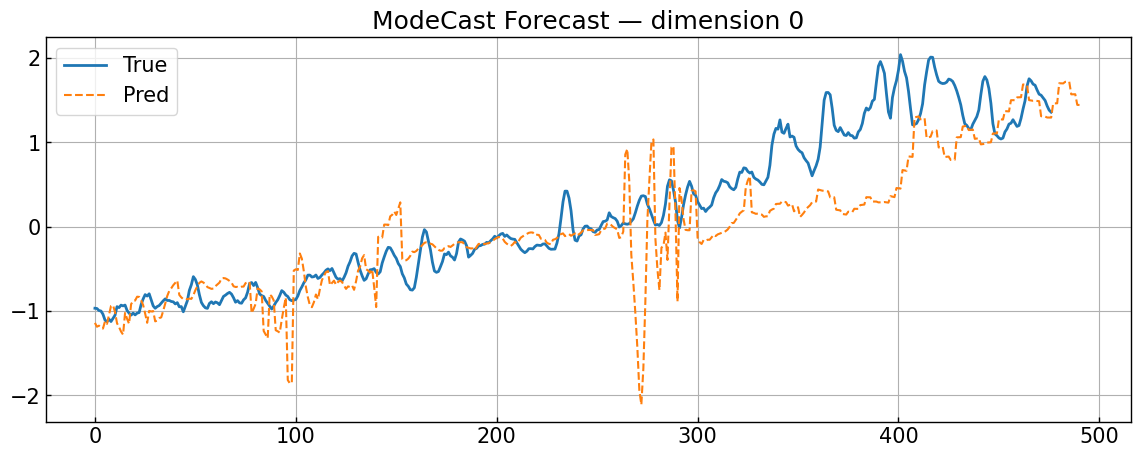

In [3]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os, sys

# プロジェクト root を import path に追加
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# MDB.pkl のパス
path = "../out/google_beer_g_ma4/streamdmd/lstep_13/lcurr_60/h_10/err_th_0.8/trunc_th_0.99/MDB.pkl"

with open(path, "rb") as f:
    mdb = pickle.load(f)

true = mdb.X
pred = mdb.Vs

valid_mask = ~np.isnan(pred).any(axis=0)
true_valid = true[:, valid_mask]
pred_valid = pred[:, valid_mask]

t = np.arange(true_valid.shape[1])

plt.figure(figsize=(14, 5))
plt.plot(t, true_valid[0], label="True", linewidth=2)
plt.plot(t, pred_valid[0], "--", label="Pred")
plt.legend()
plt.title("ModeCast Forecast — dimension 0")
plt.grid(True)
plt.show()


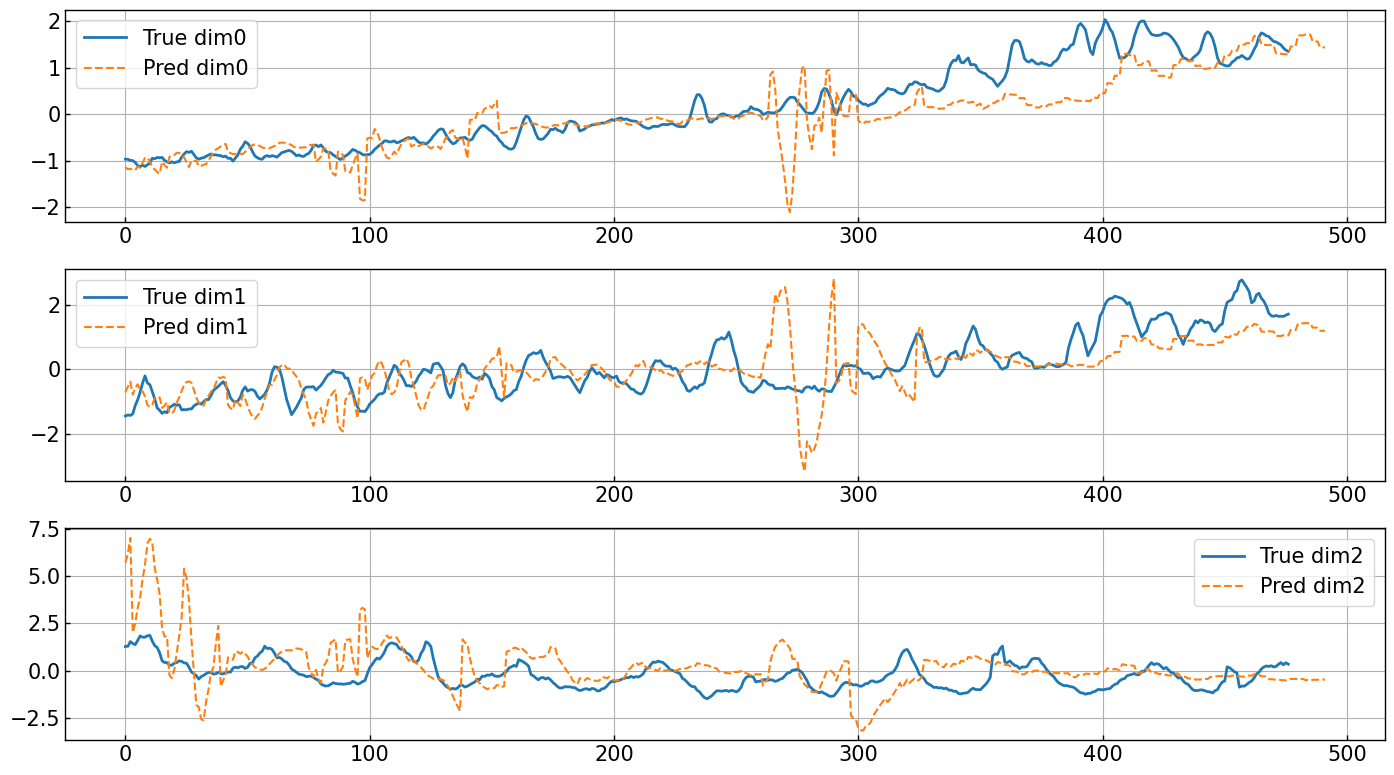

In [2]:
plt.figure(figsize=(14, 8))

for i in range(3):  # 0,1,2次元
    plt.subplot(3, 1, i+1)
    plt.plot(t, true_valid[i], label=f"True dim{i}", linewidth=2)
    plt.plot(t, pred_valid[i], "--", label=f"Pred dim{i}")
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()


In [4]:
import numpy as np

class MiniDMDc:
    """
    非モード分割版の簡易 DMDc
    X  : 過去状態 (n_x, T-1)
    Xp : 次状態   (n_x, T-1)
    U  : 入力     (n_u, T-1)

    モデル:
        Xp ≒ A X + B U
    """

    def __init__(self, trunc_th: float = 0.99, min_dim: int = 2):
        self.trunc_th = trunc_th
        self.min_dim = min_dim
        self.A_tilde = None
        self.B_tilde = None
        self.Ux = None   # 状態の基底（U と紛らわしいので Ux にした）
        self.r = None    # 有効ランク

    def _svd_trunc(self, X: np.ndarray):
        U, s, Vh = np.linalg.svd(X, full_matrices=False)
        cum = np.cumsum(s) / np.sum(s)
        r = max(int(np.argmax(cum >= self.trunc_th) + 1), self.min_dim)
        U_r = U[:, :r]
        S_r = np.diag(s[:r])
        V_r = Vh[:r, :]
        return U_r, S_r, V_r, r

    def fit(self, X: np.ndarray, Xp: np.ndarray, U: np.ndarray):
        """
        X  : (n_x, T-1)
        Xp : (n_x, T-1)
        U  : (n_u, T-1)
        """
        # 1) 状態の SVD（X のみ）
        Ux, Sx, Vx, r = self._svd_trunc(X)
        self.Ux = Ux
        self.r = r

        # 2) 低次元状態座標へ射影
        X_r  = Ux.T @ X   # (r, T-1)
        Xp_r = Ux.T @ Xp  # (r, T-1)

        # 3) [A_tilde  B_tilde] を求める
        #    Xp_r ≒ [A_tilde  B_tilde] @ [X_r; U]
        Z = np.vstack([X_r, U])          # (r + n_u, T-1)
        M = Xp_r @ np.linalg.pinv(Z)     # (r, r + n_u)
        self.A_tilde = M[:, :r]
        self.B_tilde = M[:, r:]

    def predict(self, x0: np.ndarray, U_seq: np.ndarray, with_initial: bool = False):
        """
        x0    : 初期状態 (n_x,)
        U_seq : 入力系列 (n_u, T_pred)
        """
        assert self.A_tilde is not None, "call fit() first"

        T_pred = U_seq.shape[1]
        n_x = x0.shape[0]

        # 状態を低次元空間へ
        x_r = self.Ux.T @ x0          # (r,)
        X_pred_r = np.zeros((self.r, T_pred))

        for t in range(T_pred):
            u_t = U_seq[:, t]         # (n_u,)
            x_r = self.A_tilde @ x_r + self.B_tilde @ u_t
            X_pred_r[:, t] = x_r

        # 高次元に戻す
        X_pred = self.Ux @ X_pred_r   # (n_x, T_pred)

        if with_initial:
            X_pred = np.hstack([x0.reshape(-1, 1), X_pred])

        return X_pred


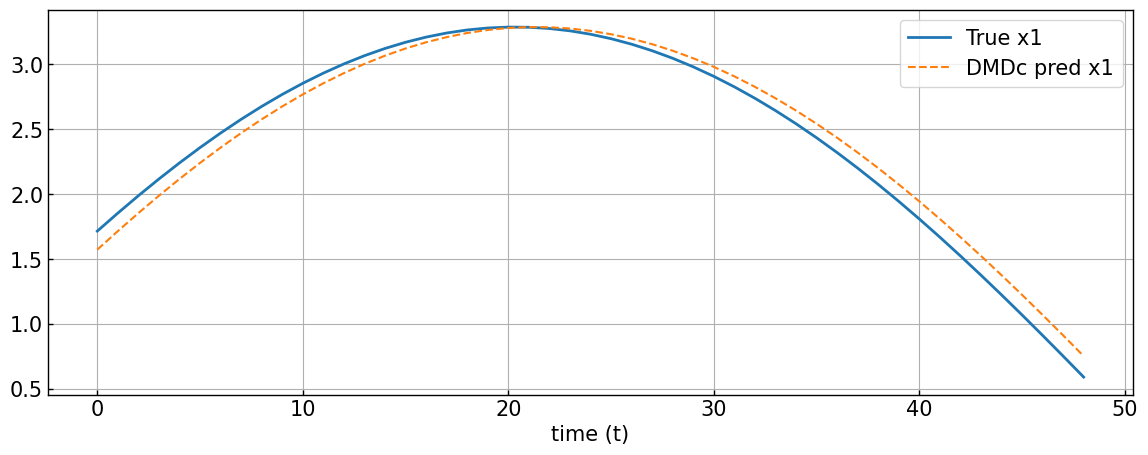

In [22]:
import matplotlib.pyplot as plt
np.random.seed(0)

# ---- 真の線形系を用意 (2次元状態, 1入力) ----
A_true = np.array([[0.9, 0.1],
                   [0.0, 0.95]])
B_true = np.array([[0.5],
                   [0.2]])

n_x = 2
n_u = 1
T   = 200   # 全長

# ---- 入力 u_t を適当に作る ----
u = 0.5 * np.sin(np.linspace(0, 10, T))  # (T,)
u = u.reshape(1, -1)                     # (1, T)

# ---- 系をシミュレーション ----
x = np.zeros((n_x, T))
x[:, 0] = np.array([0.0, 0.0])

for t in range(T-1):
    x[:, t+1] = A_true @ x[:, t] + B_true @ u[:, t]

# ---- DMDc 用の学習データを作る ----
X  = x[:, :-1]    # (n_x, T-1)
Xp = x[:, 1:]     # (n_x, T-1)
U  = u[:, :-1]    # (n_u, T-1)

# ---- 前半で学習、後半を予測対象にする ----
split = 150
X_train  = X[:, :split]
Xp_train = Xp[:, :split]
U_train  = U[:, :split]

X_test   = X[:, split-1:-1]   # 初期状態は split-1 の状態
Xp_test  = Xp[:, split-1:]    # 真のラベル
U_test   = U[:, split-1:-1]

# ---- DMDc をフィット ----
dmdc = MiniDMDc(trunc_th=0.99, min_dim=2)
dmdc.fit(X_train, Xp_train, U_train)

# ---- 初期状態 x(split-1) から未来を予測 ----
x0 = X[:, split-1]            # shape = (n_x,)
X_pred = dmdc.predict(x0, U_test, with_initial=False)   # (n_x, T_pred)

# ---- 可視化 ----
# 予測の長さに合わせた時間軸
t_axis = np.arange(X_pred.shape[1])   # 長さ 49

# 真値も 49 個にそろえる（先頭 x(0) を落とす）
Xp_true_aligned = Xp_test[:, 1:1+X_pred.shape[1]]   # shape = (2, 49)

plt.figure(figsize=(14,5))
plt.plot(t_axis, Xp_true_aligned[0], label="True x1", linewidth=2)
plt.plot(t_axis, X_pred[0], "--", label="DMDc pred x1")
plt.xlabel("time (t)")
plt.legend()
plt.grid(True)
plt.show()




In [6]:
print("Xp_test shape:", Xp_test.shape)   # (d, ?)
print("X_pred shape:", X_pred.shape)     # (d, ?)

Xp_test shape: (2, 50)
X_pred shape: (2, 49)


In [16]:
import logging

import hydra
import numpy as np
from omegaconf import DictConfig

from src.module.tsdmd import TSDMD
from src.utils import change2darkmode
from src.utils.displayer import show_input, show_metrics, show_snapshot_info
from src.utils.io_helper import IOHelper
from src.utils.mdb import MDB
from src.utils.metrics import rmse
from src.utils.preprocessor import create_variables, standardize
from src.utils.visualizer import viz_snapshot

from src.utils.preprocessor import create_variables

@hydra.main(version_base=None, config_path="config", config_name="config")
def main(cfg: DictConfig) -> None:
    # ------------------------------------ #
    #            preprocessing             #
    # ------------------------------------ #
    ioh = IOHelper(cfg.io)
    ioh.init_dir()

    data = standardize(ioh.import_arr_data(fn=cfg.io.fn, window=15)).T

    Xc, Xp, Xc_test, Xp_test = create_variables(data, lcurr=60, lstep=13)

    print("data:", data.shape)
    print("Xc:", Xc.shape)
    print("Xp:", Xp.shape)
    print("Xc_test:", Xc_test.shape)
    print("Xp_test:", Xp_test.shape)


if __name__ == "__main__":
    main()


usage: ipykernel_launcher.py [--help] [--hydra-help] [--version]
                             [--cfg {job,hydra,all}] [--resolve]
                             [--package PACKAGE] [--run] [--multirun]
                             [--shell-completion] [--config-path CONFIG_PATH]
                             [--config-name CONFIG_NAME]
                             [--config-dir CONFIG_DIR]
                             [--experimental-rerun EXPERIMENTAL_RERUN]
                             [--info [{all,config,defaults,defaults-tree,plugins,searchpath}]]
                             [overrides ...]
ipykernel_launcher.py: error: unrecognized arguments: --f=/Users/okamototakuya/Library/Jupyter/runtime/kernel-v38936bcd8ee6c1c8784fe857a98f24a745cbeddba.json


SystemExit: 2

/Users/okamototakuya/research/ModeCast-dev/.venv/lib/python3.9/site-packages/IPython/core/interactiveshell.py:3558: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [17]:
import os, sys
import numpy as np
from omegaconf import OmegaConf

# プロジェクト root を import path に追加
PROJECT_ROOT = os.path.abspath("..")  # test.ipynb が src/ にある前提
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.utils.io_helper import IOHelper
from src.utils.preprocessor import create_variables, standardize

# config 読み込み
cfg = OmegaConf.load(os.path.join(PROJECT_ROOT, "config", "config.yaml"))

ioh = IOHelper(cfg.io)
data = standardize(ioh.import_arr_data(fn=cfg.io.fn, window=15)).T

Xc, Xp, Xc_test, Xp_test = create_variables(data, lcurr=60, lstep=13)

print("data   :", data.shape)
print("Xc     :", Xc.shape)
print("Xp     :", Xp.shape)
print("Xc_test:", Xc_test.shape)
print("Xp_test:", Xp_test.shape)


FileNotFoundError: [Errno 2] No such file or directory: '/Users/okamototakuya/research/ModeCast-dev2/config/config.yaml'

In [21]:
import os, sys
import numpy as np

# Notebook が src/test.ipynb だと仮定 → プロジェクト root を PATH に追加
PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# ModeCast utils
from src.utils.io_helper import IOHelper
from src.utils.preprocessor import standardize, create_variables
from omegaconf import OmegaConf

# 🔧 config を直接ロード（Hydra使わない）
cfg_path = os.path.join(PROJECT_ROOT, "src", "config", "config.yaml")
cfg = OmegaConf.load(cfg_path)

# -------------------------
#  1. データの読み込み
# -------------------------
ioh = IOHelper(cfg.io)
data = standardize(ioh.import_arr_data(fn=cfg.io.fn, window=15)).T

print("📌 data shape =", data.shape)

# -------------------------
# 2. create_variables で分割
# -------------------------
Xc, Xp, Xc_test, Xp_test = create_variables(
    data,
    lcurr=cfg.model.lcurr,
    lstep=cfg.model.lstep
)

print("📌 Xc      =", Xc.shape)
print("📌 Xp      =", Xp.shape)
print("📌 Xc_test =", Xc_test.shape)
print("📌 Xp_test =", Xp_test.shape)


MissingMandatoryValue: Missing mandatory value: io.input_dir
    full_key: io.input_dir
    object_type=dict

In [19]:
import os, glob

PROJECT_ROOT = os.path.abspath("..")
print("PROJECT_ROOT =", PROJECT_ROOT)
print("root contents =", os.listdir(PROJECT_ROOT))

# config.yaml を再帰的に検索
for p in glob.glob(os.path.join(PROJECT_ROOT, "**", "config.yaml"), recursive=True):
    print("FOUND:", p)


PROJECT_ROOT = /Users/okamototakuya/research/ModeCast-dev2
root contents = ['.DS_Store', 'LICENSE', 'bin', 'out', 'Makefile', 'pyproject.toml', 'tests', 'docs', 'README.md', '.gitignore', '.venv', '.github', 'poetry.toml', 'poetry.lock', '.vscode', 'data', 'notebooks', 'src']
FOUND: /Users/okamototakuya/research/ModeCast-dev2/src/config/config.yaml


📌 読み込み対象： recording_2021_12_15_20H_29M.mat
dict_keys(['__header__', '__version__', '__globals__', 'recording_ok', 'q_mot_meas', 'q_se_meas', 'qd_mot_meas', 'qd_se_meas', 'tau_meas', 'tau_fb_meas', 'q_ref', 'qd_ref', 'tau_ref_ff', 'READ_ME', 'time'])


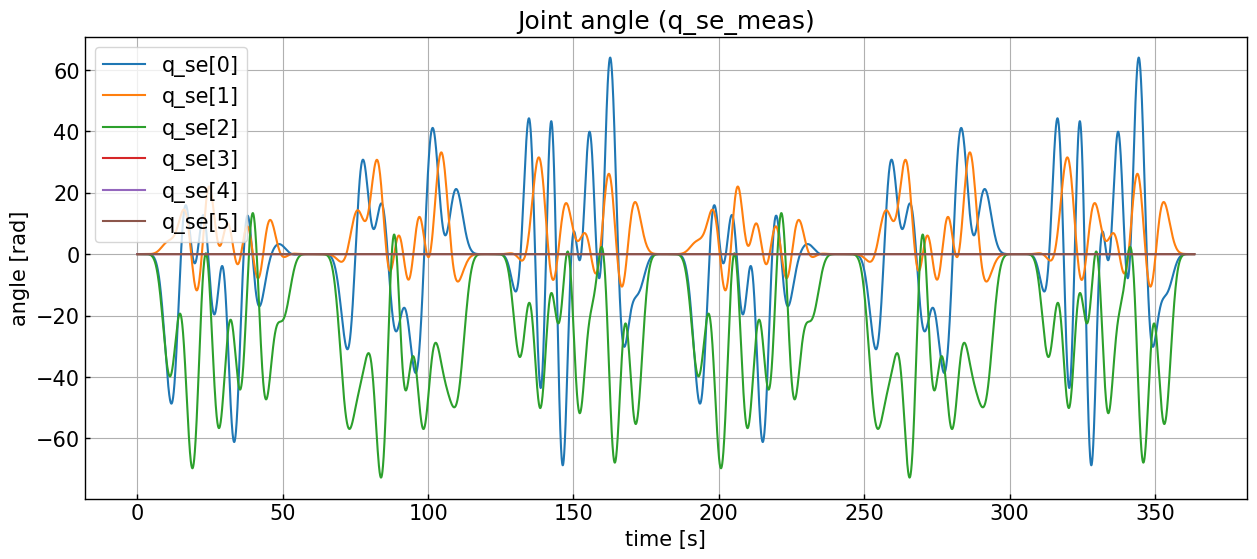

In [28]:
import os
import scipy.io as sio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Robot データパス（必要に応じて変更）
RAW_DIR = "../data/Robot/raw_data"   # test.ipynb が src/test.ipynb ならこのパスでOK

files = sorted([f for f in os.listdir(RAW_DIR) if f.endswith(".mat")])
print("📌 読み込み対象：", files[0])

time = data["time"].squeeze()
q_se = data["q_se_meas"].T   # shape: (T,6)
qd_se = data["qd_se_meas"].T
tau = data["tau_meas"].T

path = os.path.join(RAW_DIR, files[0])
data = sio.loadmat(path)

# MATファイル内の変数一覧
print(data.keys())


plt.figure(figsize=(15,6))
for i in range(q_se.shape[1]):
    plt.plot(time, q_se[:, i], label=f"q_se[{i}]")
plt.legend()
plt.title("Joint angle (q_se_meas)")
plt.xlabel("time [s]")
plt.ylabel("angle [rad]")
plt.grid(True)
plt.show()


In [30]:
files

['recording_2021_12_15_20H_29M.mat',
 'recording_2021_12_15_20H_38M.mat',
 'recording_2021_12_15_20H_45M.mat',
 'recording_2021_12_15_21H_11M.mat',
 'recording_2021_12_15_21H_32M.mat',
 'recording_2021_12_15_21H_3M.mat',
 'recording_2021_12_15_21H_41M.mat',
 'recording_2021_12_15_21H_54M.mat',
 'recording_2021_12_15_22H_10M.mat',
 'recording_2021_12_15_22H_41M.mat',
 'recording_2021_12_15_22H_50M.mat',
 'recording_2021_12_15_22H_58M.mat']

In [32]:
SAVE_DIR = "../data/Robot/robot_csv"
os.makedirs(SAVE_DIR, exist_ok=True)

for file in files:
    path = os.path.join(RAW_DIR, file)
    data = sio.loadmat(path)

    time = data["time"].squeeze()
    q_se = data["q_se_meas"].T
    qd_se = data["qd_se_meas"].T
    tau_ref = data["tau_ref_ff"].T

    df = pd.DataFrame({"time": time})
    for i in range(6):
        df[f"q_se[{i}]"] = q_se[:, i]
        df[f"qd_se[{i}]"] = qd_se[:, i]
        df[f"tau_ref_ff[{i}]"] = tau_ref[:, i]

    csv_path = os.path.join(SAVE_DIR, file.replace(".mat", ".csv"))
    df.to_csv(csv_path, index=False)

print("✔ すべてCSV化完了！")


✔ すべてCSV化完了！


In [33]:
import os
import pandas as pd
import matplotlib.pyplot as plt

CSV_DIR = "../data/Robot/robot_csv"

csv_files = sorted([f for f in os.listdir(CSV_DIR) if f.endswith(".csv")])
print("📁 CSV files:", len(csv_files))
print(csv_files[:5])   # 最初の5つだけ表示


📁 CSV files: 12
['recording_2021_12_15_20H_29M.csv', 'recording_2021_12_15_20H_38M.csv', 'recording_2021_12_15_20H_45M.csv', 'recording_2021_12_15_21H_11M.csv', 'recording_2021_12_15_21H_32M.csv']


In [34]:
def load_robot_csv(filename):
    path = os.path.join(CSV_DIR, filename)
    df = pd.read_csv(path)
    return df


In [35]:
def plot_robot_csv(df, title=""):
    time = df["time"].values

    # Joint angle
    plt.figure(figsize=(14,4))
    for i in range(6):
        plt.plot(time, df[f"q_se[{i}]"], label=f"q_se[{i}]")
    plt.title("Joint Angle (q_se) " + title)
    plt.xlabel("time"); plt.ylabel("angle"); plt.legend(); plt.grid()
    plt.show()

    # Joint velocity
    plt.figure(figsize=(14,4))
    for i in range(6):
        plt.plot(time, df[f"qd_se[{i}]"], label=f"qd_se[{i}]")
    plt.title("Joint Velocity (qd_se) " + title)
    plt.xlabel("time"); plt.ylabel("velocity"); plt.legend(); plt.grid()
    plt.show()

    # Torque Input
    plt.figure(figsize=(14,4))
    for i in range(6):
        plt.plot(time, df[f"tau_ref_ff[{i}]"], label=f"tau_ref_ff[{i}]")
    plt.title("Torque Command (tau_ref_ff) " + title)
    plt.xlabel("time"); plt.ylabel("torque"); plt.legend(); plt.grid()
    plt.show()


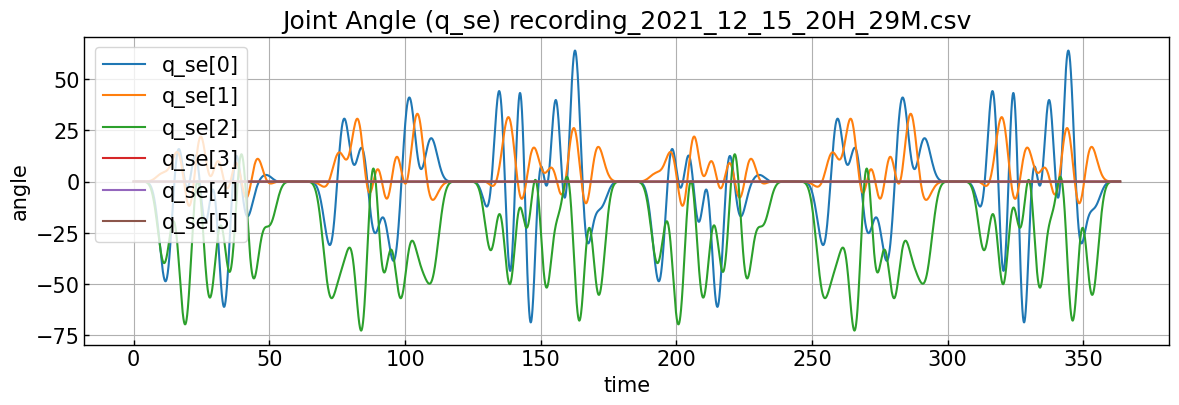

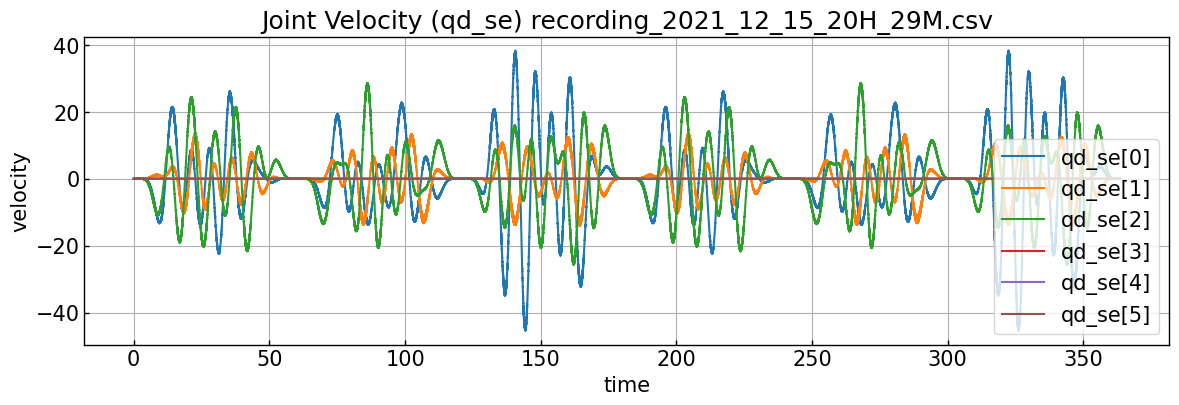

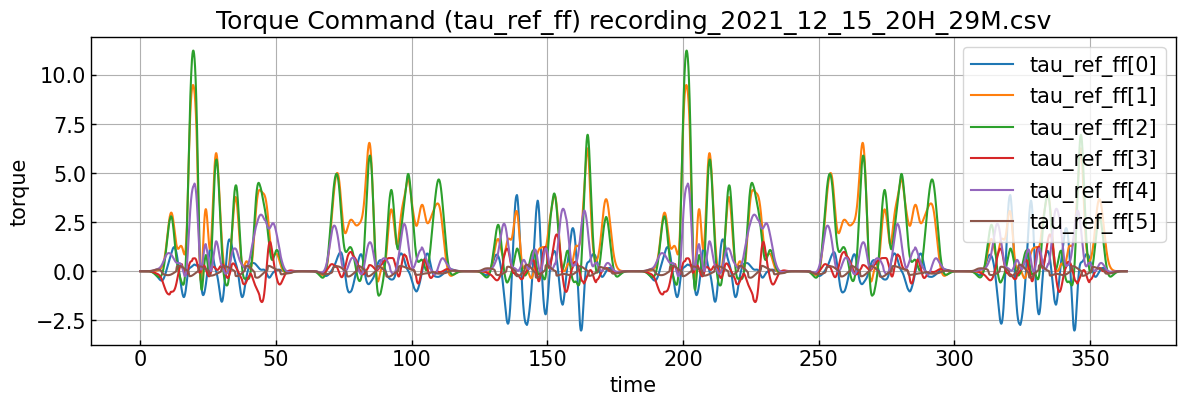

In [36]:
df = load_robot_csv(csv_files[0])
plot_robot_csv(df, title=csv_files[0])


In [39]:
import os
import scipy.io as sio
import pandas as pd
import numpy as np

# 生データの場所（前と同じ想定）
RAW_DIR = "../data/Robot/raw_data"

# 新しくフル版CSVを保存するフォルダ
SAVE_DIR_FULL = "../data/Robot/robot_csv_full"
os.makedirs(SAVE_DIR_FULL, exist_ok=True)

mat_files = sorted([f for f in os.listdir(RAW_DIR) if f.endswith(".mat")])
print("対象MATファイル数:", len(mat_files))

for fname in mat_files:
    path = os.path.join(RAW_DIR, fname)
    data = sio.loadmat(path)

    # 時刻
    time = data["time"].squeeze()              # (T,)

    # 各種データを (T, 6) 形状にそろえる
    def to_T6(key):
        arr = data[key].squeeze()
        if arr.ndim == 1:
            # ありえないはずだけど保険
            arr = arr[:, None]
        # 通常は (6, T) なので転置して (T, 6)
        if arr.shape[0] == 6:
            arr = arr.T
        return arr

    q_mot     = to_T6("q_mot_meas")    # (T,6)
    qd_mot    = to_T6("qd_mot_meas")
    q_se      = to_T6("q_se_meas")
    qd_se     = to_T6("qd_se_meas")
    tau_meas  = to_T6("tau_meas")
    tau_fb    = to_T6("tau_fb_meas")
    tau_ref   = to_T6("tau_ref_ff")
    q_ref     = to_T6("q_ref")
    qd_ref    = to_T6("qd_ref")

    # DataFrame にまとめる
    df = pd.DataFrame({"time": time})

    for i in range(6):
        df[f"q_mot[{i}]"]    = q_mot[:, i]
        df[f"qd_mot[{i}]"]   = qd_mot[:, i]
        df[f"q_se[{i}]"]     = q_se[:, i]
        df[f"qd_se[{i}]"]    = qd_se[:, i]
        df[f"tau_meas[{i}]"] = tau_meas[:, i]
        df[f"tau_fb[{i}]"]   = tau_fb[:, i]
        df[f"tau_ref_ff[{i}]"] = tau_ref[:, i]
        df[f"q_ref[{i}]"]    = q_ref[:, i]
        df[f"qd_ref[{i}]"]   = qd_ref[:, i]

    csv_name = fname.replace(".mat", "_full.csv")
    csv_path = os.path.join(SAVE_DIR_FULL, csv_name)
    df.to_csv(csv_path, index=False)

    print("✅ saved:", csv_path)

print("🎉 全部入りCSVの書き出し完了！")


対象MATファイル数: 12
✅ saved: ../data/Robot/robot_csv_full/recording_2021_12_15_20H_29M_full.csv
✅ saved: ../data/Robot/robot_csv_full/recording_2021_12_15_20H_38M_full.csv
✅ saved: ../data/Robot/robot_csv_full/recording_2021_12_15_20H_45M_full.csv
✅ saved: ../data/Robot/robot_csv_full/recording_2021_12_15_21H_11M_full.csv
✅ saved: ../data/Robot/robot_csv_full/recording_2021_12_15_21H_32M_full.csv
✅ saved: ../data/Robot/robot_csv_full/recording_2021_12_15_21H_3M_full.csv
✅ saved: ../data/Robot/robot_csv_full/recording_2021_12_15_21H_41M_full.csv
✅ saved: ../data/Robot/robot_csv_full/recording_2021_12_15_21H_54M_full.csv
✅ saved: ../data/Robot/robot_csv_full/recording_2021_12_15_22H_10M_full.csv
✅ saved: ../data/Robot/robot_csv_full/recording_2021_12_15_22H_41M_full.csv
✅ saved: ../data/Robot/robot_csv_full/recording_2021_12_15_22H_50M_full.csv
✅ saved: ../data/Robot/robot_csv_full/recording_2021_12_15_22H_58M_full.csv
🎉 全部入りCSVの書き出し完了！


In [41]:
import os
import pandas as pd

CSV_FULL_DIR = "../data/Robot/robot_csv_full"
csv_files_full = sorted([f for f in os.listdir(CSV_FULL_DIR) if f.endswith(".csv")])

print("フルCSV数:", len(csv_files_full))
print("一つ目:", csv_files_full[0])

df_full = pd.read_csv(os.path.join(CSV_FULL_DIR, csv_files_full[0]))
print("列数:", df_full.shape[1])
print("列名サンプル:", df_full.columns[:20])


フルCSV数: 12
一つ目: recording_2021_12_15_20H_29M_full.csv
列数: 55
列名サンプル: Index(['time', 'q_mot[0]', 'qd_mot[0]', 'q_se[0]', 'qd_se[0]', 'tau_meas[0]',
       'tau_fb[0]', 'tau_ref_ff[0]', 'q_ref[0]', 'qd_ref[0]', 'q_mot[1]',
       'qd_mot[1]', 'q_se[1]', 'qd_se[1]', 'tau_meas[1]', 'tau_fb[1]',
       'tau_ref_ff[1]', 'q_ref[1]', 'qd_ref[1]', 'q_mot[2]'],
      dtype='object')


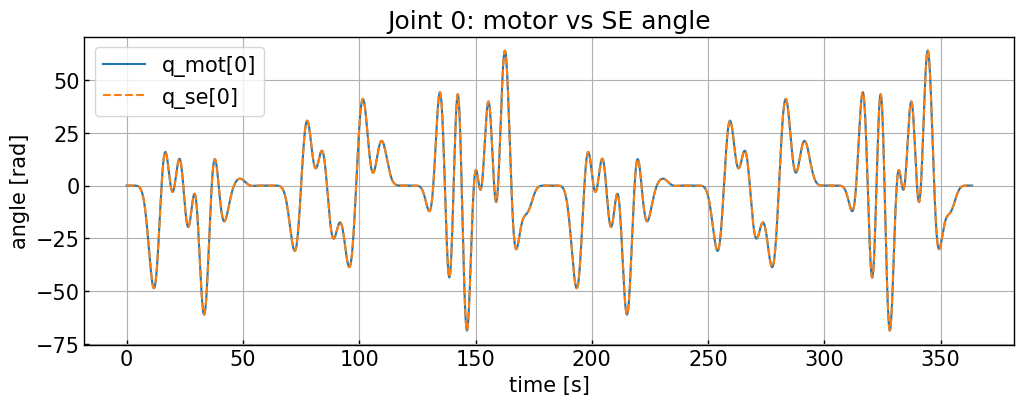

In [42]:
import matplotlib.pyplot as plt

df = pd.read_csv(os.path.join(CSV_FULL_DIR, csv_files_full[0]))

time = df["time"].values

plt.figure(figsize=(12,4))
plt.plot(time, df["q_mot[0]"], label="q_mot[0]")
plt.plot(time, df["q_se[0]"],  label="q_se[0]", linestyle="--")
plt.xlabel("time [s]")
plt.ylabel("angle [rad]")
plt.title("Joint 0: motor vs SE angle")
plt.legend()
plt.grid(True)
plt.show()
